In [2]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [3]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 5. 图像梯度计算
</font>


In [10]:
picture = '../Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print("img.shape = " , img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

<font color = #000000>

### 5-1 Sobel算子
+ 算子:
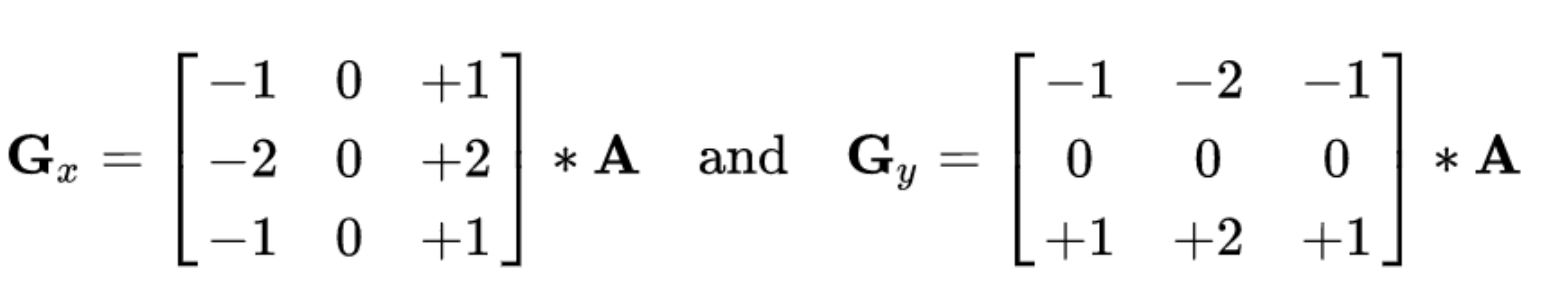

<font color = #f20e0e>

- dst = cv2.Sobel(src, ddepth, dx, dy, ksize)
    - ddepth:图像的深度,输出图像的数据类型
        - 原始图像通常是 uint8（0~255），无法表示负值或大于 255 的值,求梯度之后可能越界,所以需要修改输出图像的数据类型为ddepth
        - 例如 CV_8U、CV_16S、CV_32F、CV_64F
        - 后续需要将负数转为uint8正数才能正确显示图像
    - dx和dy分别表示要检测水平还是竖直方向还是都(一般建议不要都,最好是分别计算然后合并)(dx表示x方向求导阶数（1 表示一阶导）)
    - ksize是Sobel算子卷积核的大小
</font>

<font color = #f20e0e>

+ 注意点
    + 传入的图像需要是灰度图
    + 
</font>
</font>

In [5]:
# 1. 先读取图像
img = cv2.imread(picture + 'pie.png',cv2.IMREAD_GRAYSCALE)  # 传入的图像需要是灰度图
# 2. 水平方向计算梯度,寻找边缘
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
# 3. 竖直方向计算梯度,寻找边缘
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
# 4. 计算完之后需要将64F转为uint8(Scale : 0-255,还需要绝对值: Abs)
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.convertScaleAbs(sobely)
# 5. x 和 y 方向合并,dst = α*A + β*B + γ, α,β可以大于1,自己调
sobelxy = cv2.addWeighted(sobelx,0.5,sobely,0.5,0)  # 最后一位gamma不用管,为0即可
# 6. 展示效果
res = np.hstack((sobelx,sobely,sobelxy))  # 还有vstack:竖着展示
img_show(res)

(489, 1638)


<font color = #000000>

### 5-2 Scharr算子 和 laplacian算子

+ Scharr算子
    + 更加敏感
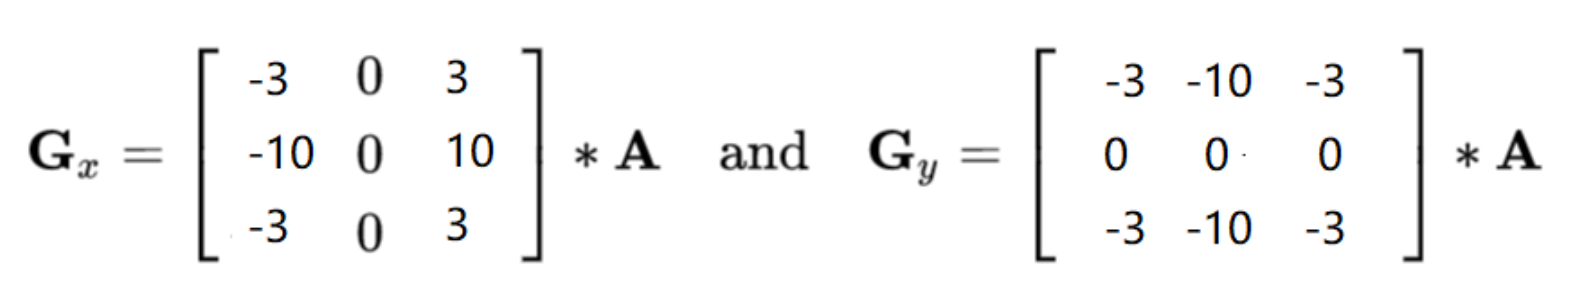

+ laplacian算子

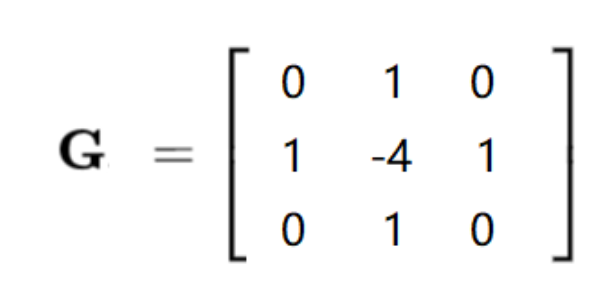

</font>

In [ ]:
# 不同算子的差异
img = cv2.imread(picture + 'lena.jpg' , cv2.IMREAD_GRAYSCALE)   # 转成灰度
# sobel算子:捕获大题
sobelx = cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.convertScaleAbs(sobely)
sobelxy = cv2.addWeighted(sobelx,0.5,sobely,0.5,0)
# Scharr算子:捕获的梯度更加精细
scharrx = cv2.Scharr(img , cv2.CV_64F , 1 , 0)
scharry = cv2.Scharr(img , cv2.CV_64F , 0 , 1)
scharrx = cv2.convertScaleAbs(scharrx)
scharry = cv2.convertScaleAbs(scharry)
scharrxy = cv2.addWeighted(scharrx,0.5,scharry,0.5,0)
# laplacian算子:后续搭配其他方法使用
laplacian = cv2.Laplacian(img , cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
# 展示
res = np.hstack((sobelxy , scharrxy , laplacian))
img_show(res)

img.shape =  (263, 789)


<font color = #000000>

### 5-5 


</font>

<font color = #000000>

### 参考格式
</font>